<a href="https://colab.research.google.com/github/kshamie3505-a11y/Codveda-Internship-Tasks/blob/main/Level2Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 3: Clustering (Unsupervised
Learning)**
Description: Implement K-Means clustering to group
data points into clusters without labels (e.g.,
customer segmentation).

**Loading the customer segmentation dataset**

In [6]:
import pandas as pd
df = pd.read_excel('/content/Online Retail.xlsx')
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


**Data Inspection**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [8]:
df.shape

(541909, 8)

In [9]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [10]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


**Checking the data for Missing Values**

In [11]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


**Dropping rows with missing values in CustomerID column and those with negative values in Quantity and unit Price columns**

In [12]:
df.dropna(subset=['CustomerID'], inplace=True)
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
print(f"DataFrame shape after cleaning: {df.shape}")

DataFrame shape after cleaning: (397884, 8)


**Calculating the TotalPrice for each transaction to be used in calculating the monetary value**

In [13]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


**Calculating RFM Features**

Computing Recency, Frequency, and Monetary (RFM) values for each customer. Recency = number of days since the last purchase, Frequency = total number of unique invoices, and Monetary = sum of total spending for each customer.


In [14]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1) # Snapshot_date represents one day after the last transaction in the entire dataset

# Combining RFM into a single DataFrame
rfm_df = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda date: (snapshot_date - date.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(rfm_df.head())
print(rfm_df.info())

   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4338 non-null   float64
 1   Recency     4338 non-null   int64  
 2   Frequency   4338 non-null   int64  
 3   Monetary    4338 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 135.7 KB
None



**Applying log transformation, to handle skewed distributions and scaling the features using StandardScaler.It ensures that all features contribute equally to the distance calculations in K-Means.**


In [15]:
import numpy as np
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully.")

Libraries imported successfully.


In [16]:
rfm_log = rfm_df.copy()
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['Recency', 'Frequency', 'Monetary']])

rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'])
rfm_scaled_df['CustomerID'] = rfm_df['CustomerID']

print("First 5 rows of scaled RFM features:")
print(rfm_scaled_df.head())
print("\nDescriptive statistics of scaled RFM features:")
print(rfm_scaled_df.describe())

First 5 rows of scaled RFM features:
   Recency_scaled  Frequency_scaled  Monetary_scaled  CustomerID
0        1.461993         -0.955214         3.706225     12346.0
1       -2.038734          1.074425         1.411843     12347.0
2        0.373104          0.386304         0.716489     12348.0
3       -0.623086         -0.955214         0.698739     12349.0
4        1.424558         -0.955214        -0.618962     12350.0

Descriptive statistics of scaled RFM features:
       Recency_scaled  Frequency_scaled  Monetary_scaled    CustomerID
count    4.338000e+03      4.338000e+03     4.338000e+03   4338.000000
mean    -9.172520e-17     -7.206980e-17     2.882792e-16  15300.408022
std      1.000115e+00      1.000115e+00     1.000115e+00   1721.808492
min     -2.341296e+00     -9.552143e-01    -4.004574e+00  12346.000000
25%     -6.613615e-01     -9.552143e-01    -6.856676e-01  13813.250000
50%      8.992557e-02     -3.615828e-01    -6.218718e-02  15299.500000
75%      8.447915e-01      6


**Using the Elbow method and/or Silhouette Score to identify the optimal number of clusters (k) for the K-Means algorithm.**


**Importing the necessary libraries for K-Means clustering, the silhouette score, and matplotlib for plotting/visualization.**



In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

print("KMeans, silhouette_score, and matplotlib.pyplot imported successfully.")

KMeans, silhouette_score, and matplotlib.pyplot imported successfully.


**Calculating the sum of squared errors(SSE) and Silhouette Scores for a range of cluster numbers (k) using the Elbow method and Silhouette Score, respectively. Then, plotting both metrics against the number of clusters to visually identify the optimal 'k'.**



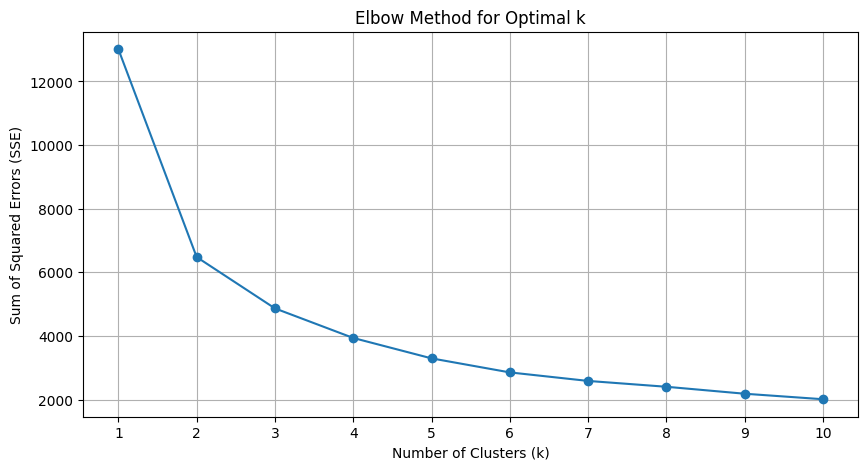

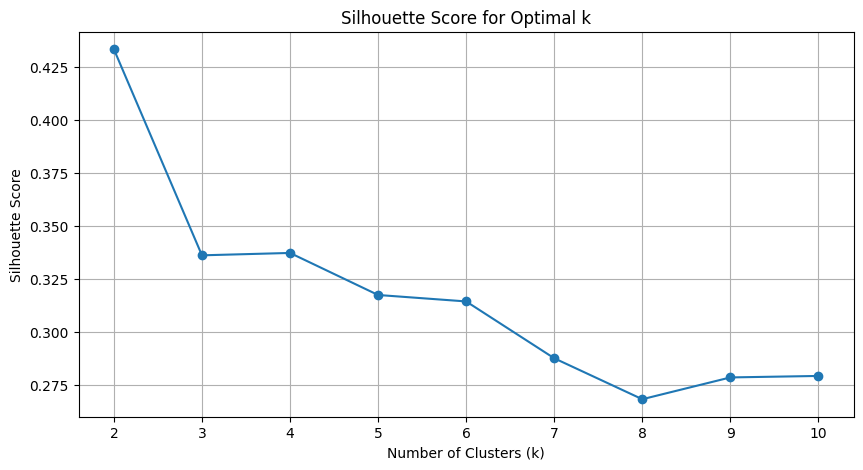

In [18]:
sse = [] # Sum of Squared Errors(Inertia)
silhouette_scores = []
k_range = range(1, 11)

# Exclude CustomerID from scaling for clustering
rfm_scaled_data = rfm_scaled_df[['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']].values

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(rfm_scaled_data)
    sse.append(kmeans.inertia_)

    if k > 1:
        # Calculate silhouette score only if k > 1
        score = silhouette_score(rfm_scaled_data, kmeans.labels_)
        silhouette_scores.append(score)

# Plotting the Elbow Method
plt.figure(figsize=(10, 5))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Plotting the Silhouette Score
plt.figure(figsize=(10, 5))
plt.plot(k_range[1:], silhouette_scores, marker='o') # k_range[1:] because silhouette starts from k=2
plt.title('Silhouette Score for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range[1:])
plt.grid(True)
plt.show()


**Plot results from the Elbow method and Silhouette Score plots, show an optimal number of clusters to be around k=3.Apply K-Means clustering with this chosen optimal 'k' to the scaled RFM data.**



In [19]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
rfm_df['Cluster'] = kmeans.fit_predict(rfm_scaled_data)

print(f"Distribution of customers per cluster (k={optimal_k}):")
print(rfm_df['Cluster'].value_counts().sort_index())

Distribution of customers per cluster (k=3):
Cluster
0    1696
1     776
2    1866
Name: count, dtype: int64


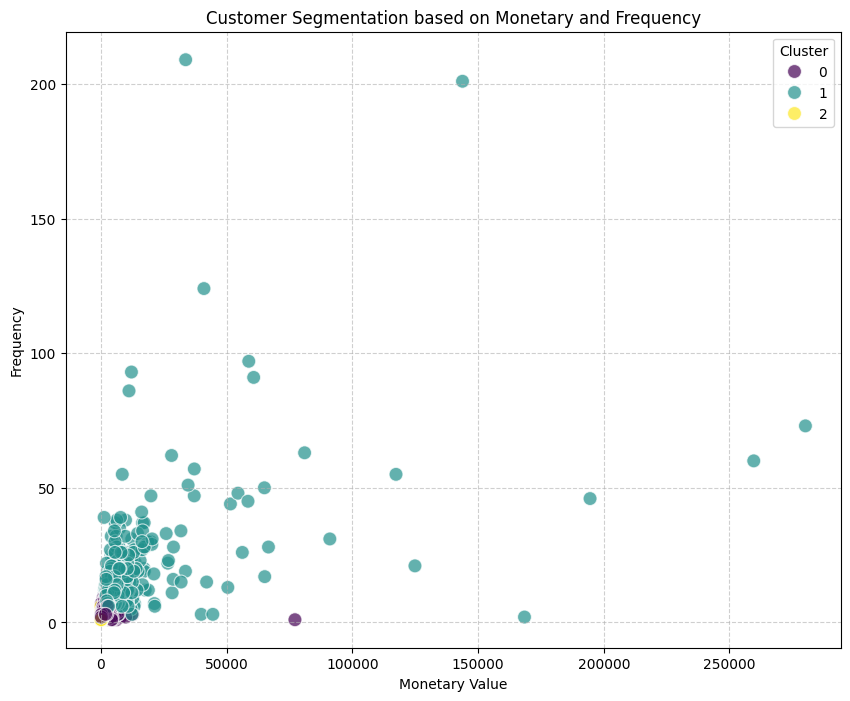

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Monetary', y='Frequency', hue='Cluster', data=rfm_df, palette='viridis', s=100, alpha=0.7)
plt.title('Customer Segmentation based on Monetary and Frequency')
plt.xlabel('Monetary Value')
plt.ylabel('Frequency')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

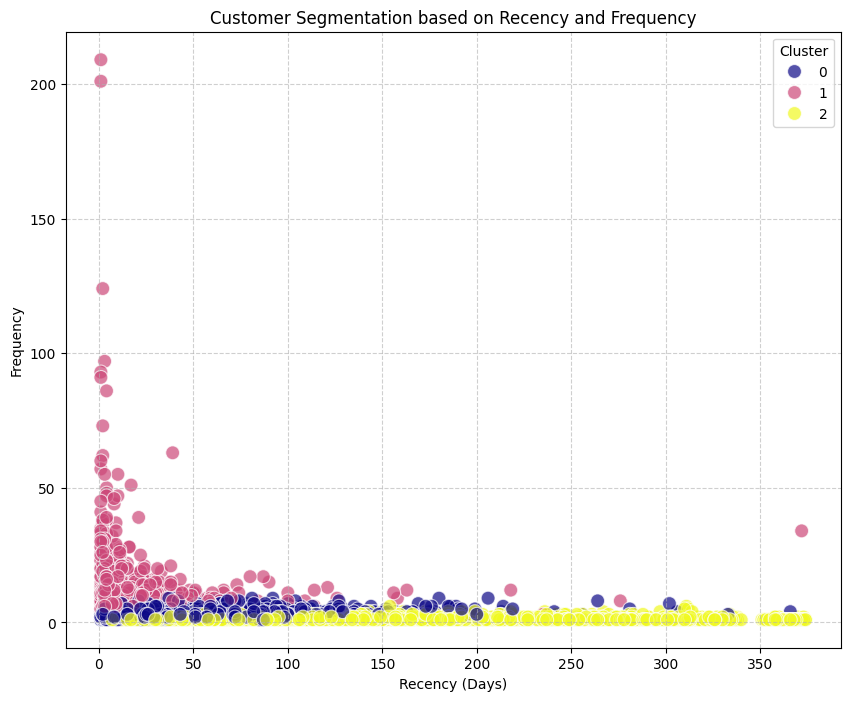

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Recency', y='Frequency', hue='Cluster', data=rfm_df, palette='plasma', s=100, alpha=0.7)
plt.title('Customer Segmentation based on Recency and Frequency')
plt.xlabel('Recency (Days)')
plt.ylabel('Frequency')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

 **Perform Dimensionality Reduction (PCA) and Visualize Clusters:**

Applying Principal Component Analysis (PCA) to the scaled RFM data to reduce its dimensionality to 2 components, createing a scatter plot of the two principal components to visualize the customer segments in a reduced 2D space.

In [22]:
# Importing PCA libraries to perform dimensionality reduction on the scaled RFM data
from sklearn.decomposition import PCA

print("PCA imported successfully.")

PCA imported successfully.


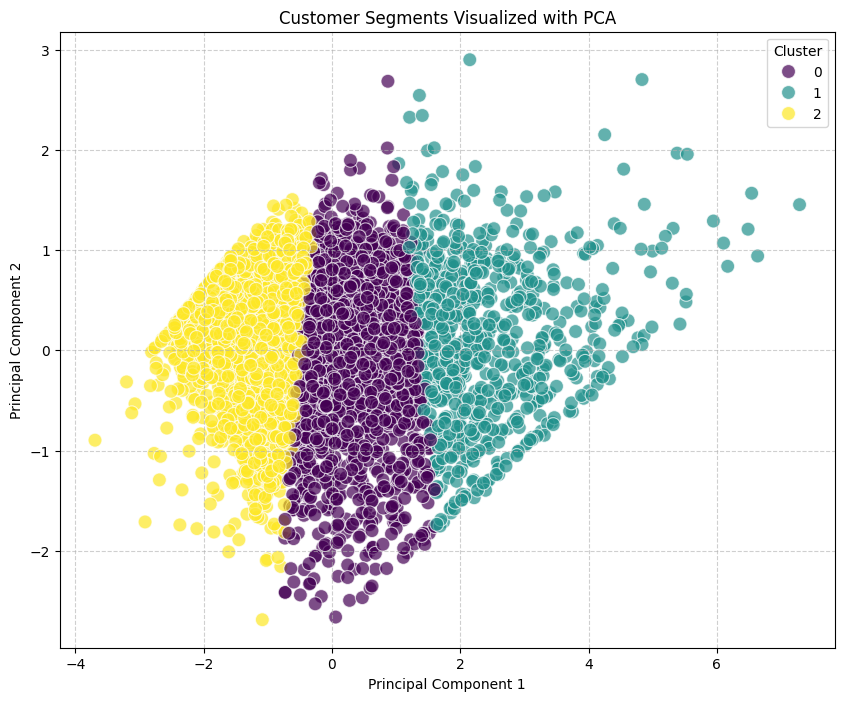

PCA dimensionality reduction and visualization completed.


In [23]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(rfm_scaled_data)

pca_df = pd.DataFrame(data=pca_components, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Cluster'] = rfm_df['Cluster']

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster', data=pca_df, palette='viridis', s=100, alpha=0.7)
plt.title('Customer Segments Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("PCA dimensionality reduction and visualization completed.")

## Final Task

### Subtask:
Summarize the customer segments identified by the clustering, describing their key characteristics based on RFM values, and discuss potential business implications.


 **Summary**

The customer segmentation analysis identified three distinct customer segments based on their RFM values.

*   **Cluster 0 (Medium Value Customers):** These customers have a medium Recency (average of 44 days since last purchase), medium Frequency (average of 3.37 invoices), and medium Monetary value (average total spending of \$1257.69).
*   **Cluster 1 (High Value/Loyal Customers):** This segment represents the most valuable customers with the lowest Recency (average of 17.07 days), highest Frequency (average of 13.27 invoices), and highest Monetary value (average total spending of \$7865.64).
*   **Cluster 2 (Low Value/Dormant Customers):** This cluster consists of customers with the highest Recency (average of 167.61 days), lowest Frequency (average of 1.35 invoices), and lowest Monetary value (average total spending of \$361.54).

### Data Analysis Key Findings
*   The initial dataset was cleaned by dropping rows with missing `CustomerID` and removing negative `Quantity` or `UnitPrice` values, resulting in a DataFrame of (397884, 8) rows and columns.
*   Recency, Frequency, and Monetary (RFM) features were successfully calculated for 4338 unique customers.
*   RFM features were log-transformed to handle skewed distributions and then scaled using `StandardScaler` to prepare them for K-Means clustering.
*   Both the Elbow method and Silhouette Score indicated that the optimal number of clusters for the K-Means algorithm is 3.
*   The K-Means clustering resulted in three distinct customer segments:
    *   **Cluster 0 (Medium Value Customers):** Comprises 1696 customers with average Recency of 44 days, Frequency of 3.37, and Monetary value of \$1257.69.
    *   **Cluster 1 (High Value/Loyal Customers):** Comprises 776 customers, characterized by the lowest Recency (17.07 days), highest Frequency (13.27), and highest Monetary value (\$7865.64).
    *   **Cluster 2 (Low Value/Dormant Customers):** Comprises 1866 customers, showing the highest Recency (167.61 days), lowest Frequency (1.35), and lowest Monetary value (\$361.54).

### Insights or Next Steps
*   **Tailored Marketing Strategies:** Develop specific marketing campaigns for each segment. For example, reward programs and exclusive offers for "High Value/Loyal Customers" (Cluster 1), re-engagement campaigns for "Low Value/Dormant Customers" (Cluster 2), and upselling/cross-selling strategies for "Medium Value Customers" (Cluster 0).
*   **Customer Lifetime Value (CLV) Prediction:** Utilize these segments to build predictive models for Customer Lifetime Value, allowing for more targeted resource allocation and strategic planning.
